# SENTINEL-WM | Phase 6b - Forward Simulation (infiltration prediction engine)

K-step Monte-Carlo rollout of the learned state-transition dynamics:
for each anchor window, `P(attack)` at +10..+60 s with a 95% CI, the
predicted progression state, and the MITRE ATT&CK phase + confidence.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, forward_sim as FS
device = C.resolve_device('auto')

## 5.1  Simulate the whole test split

In [3]:
res = FS.simulate_split('test', limit=None, device=device, with_explain=False)
print(len(res), 'anchors,', sum(r['alert'] for r in res), 'alerts')
FS.print_timeline(res, max_rows=25)

2602 anchors, 523 alerts

   win now | + 10s + 20s + 30s + 40s + 50s + 60s  | phase@peak (conf)
------------------------------------------------------------------------------
   365   0 |  0.73  0.67  0.61  0.50  0.41  0.35  | Attack (unspecified) Low     ALERT
   366   0 |  0.73  0.62  0.51  0.45  0.33  0.26  | None             Medium  ALERT
   367   0 |  0.49  0.32  0.22  0.15  0.14  0.09  | None             Medium  ALERT
   383   0 |  0.52  0.37  0.31  0.24  0.19  0.16  | None             Medium  ALERT
   385   0 |  0.72  0.55  0.47  0.38  0.31  0.23  | None             Medium  ALERT
   386   1 |  0.70  0.58  0.46  0.35  0.29  0.25  | None             Medium  ALERT
   387   1 |  0.67  0.54  0.41  0.32  0.28  0.22  | None             Medium  ALERT
   388   1 |  0.56  0.43  0.34  0.26  0.22  0.19  | None             Medium  ALERT
   389   1 |  0.45  0.31  0.21  0.16  0.12  0.08  | None             Medium  ALERT
   390   1 |  0.49  0.38  0.30  0.20  0.15  0.13  | None             Mediu

## 5.2  One attack trajectory with confidence band

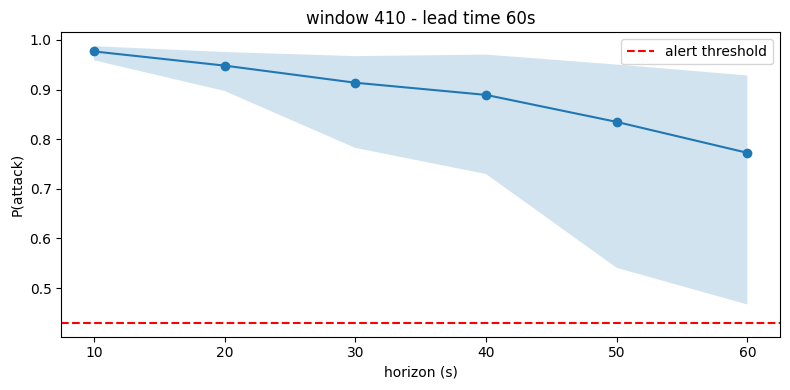

In [4]:
atk = sorted([r for r in res if r['meta'].get('y_now')==1], key=lambda r:-r['max_attack_prob'])
r = atk[0]; hz = r['horizon']; ks=[h['horizon_seconds'] for h in hz]
plt.figure(figsize=(8,4))
plt.plot(ks,[h['attack_prob'] for h in hz],'o-')
plt.fill_between(ks,[h['attack_ci'][0] for h in hz],[h['attack_ci'][1] for h in hz],alpha=.2)
plt.axhline(r['alert_threshold'],color='r',ls='--',label='alert threshold')
plt.xlabel('horizon (s)'); plt.ylabel('P(attack)'); plt.legend()
plt.title(f"window {r['meta']['window_index']} - lead time {r['lead_time_seconds']}s"); plt.tight_layout()

## 5.3  ATT&CK stage forecast table

In [5]:
rows=[]
for h in r['horizon']:
    a=h['attck']
    rows.append(dict(horizon_s=h['horizon_seconds'], p_attack=round(h['attack_prob'],3),
                     state=h['progression_state'], phase=a['kill_chain_phase'],
                     conf=a['confidence'], techniques=';'.join(a['technique_ids'])))
pd.DataFrame(rows)

,horizon_s,p_attack,state,phase,conf,techniques
0,10,0.977,ACTIVE,Impact,Medium,T1499;T1499.003
1,20,0.948,ACTIVE,Impact,Medium,T1499;T1499.003
2,30,0.914,ACTIVE,Impact,Medium,T1499;T1499.003
3,40,0.889,ACTIVE,Impact,Low,T1499;T1499.003
4,50,0.835,ACTIVE,Impact,Low,T1499;T1499.003
5,60,0.773,ACTIVE,Impact,Low,T1499;T1499.003


Full run + CSV: `../research/simulations/forward_sim_test.json`,
`../research/simulations/attck_stage_forecast.csv`.